# Spectral Analysis of Phase Angle Time Series for Muscle Fatigue Assessment

## Important Conceptual Distinction

**Two different "frequencies" in BIA analysis:**

1. **Electrical frequency (fc)**: The frequency of injected current (5-500 kHz)
   - In our protocol: **fixed at 50 kHz**
   - Used in Cole model for bioimpedance spectroscopy (BIS)
   - Determines tissue penetration depth

2. **Temporal frequency (f)**: How PhA(t) fluctuates over time (Hz = cycles/second)
   - What we analyze in this notebook: **FFT/Welch of PhA(t)**
   - Reflects system dynamics: tremor, instability, regulation
   - Sampling rate dependent (typically 0.1-10 Hz range)

---

## Objective

Compare the temporal frequency content of Phase Angle time series:
- **PRE-fatigue**: PhA_pre(t) 
- **POST-fatigue**: PhA_post(t)

**Hypothesis:** Muscle fatigue alters the temporal dynamics of PhA, detectable through spectral analysis.

**Methods:**
1. FFT Power Spectrum
2. Welch's Method (robust PSD estimation)
3. Butterworth Filtering (data-driven cutoff selection)
4. Frequency Band Power Comparison

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import welch, butter, filtfilt, detrend
from scipy.fft import rfft, rfftfreq

# Plotting configuration
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Loading and Preprocessing

Load the same data from the raw import notebook.

In [2]:
# Configuration
BIA_PKL_PATH = "../data/LEA_BIA_RAW.pkl"
FREQ_COL = "f_48800"  # ~50 kHz complex impedance

# Time windows
PRE_START_TIME  = "2025-11-28 14:57:02.563"
PRE_END_TIME    = "2025-11-28 15:00:02.563"
POST_START_TIME = "2025-11-28 15:05:45.278"
POST_END_TIME   = "2025-11-28 15:08:44.534"

# Load data
data_bia_raw = pd.read_pickle(BIA_PKL_PATH)
print(f"Data loaded: {data_bia_raw.shape[0]} rows")

# Process
data_bia = data_bia_raw.copy()
data_bia["time"] = pd.to_datetime(data_bia["timestamp"], errors="coerce")
data_bia = data_bia.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

# Compute Phase Angle at 50 kHz (electrical frequency)
data_bia["Z_50k"] = data_bia[FREQ_COL].astype(np.complex128)
data_bia["R_50k_ohm"] = np.real(data_bia["Z_50k"])
data_bia["Xc_50k_ohm"] = -np.imag(data_bia["Z_50k"])
data_bia["PhA_50k_deg"] = np.degrees(np.arctan2(data_bia["Xc_50k_ohm"], data_bia["R_50k_ohm"]))

print(f"Phase Angle computed: mean = {data_bia['PhA_50k_deg'].mean():.2f}°")

Data loaded: 4743 rows
Phase Angle computed: mean = 8.72°


In [3]:
# Extract PRE and POST windows
def slice_window(df, t0, t1):
    mask = (df["time"] >= t0) & (df["time"] <= t1)
    return df.loc[mask].copy()

pre_start  = pd.to_datetime(PRE_START_TIME)
pre_end    = pd.to_datetime(PRE_END_TIME)
post_start = pd.to_datetime(POST_START_TIME)
post_end   = pd.to_datetime(POST_END_TIME)

bia_pre  = slice_window(data_bia, pre_start, pre_end)
bia_post = slice_window(data_bia, post_start, post_end)

# Extract Phase Angle time series
pha_pre  = bia_pre["PhA_50k_deg"].astype(float).dropna().to_numpy()
pha_post = bia_post["PhA_50k_deg"].astype(float).dropna().to_numpy()

# Time vectors (seconds from start)
t_pre  = (bia_pre["time"] - bia_pre["time"].iloc[0]).dt.total_seconds().to_numpy()
t_post = (bia_post["time"] - bia_post["time"].iloc[0]).dt.total_seconds().to_numpy()

# Sampling rate estimation
dt_pre_med  = float(bia_pre["time"].diff().dt.total_seconds().median())
dt_post_med = float(bia_post["time"].diff().dt.total_seconds().median())
fs_pre  = 1.0 / dt_pre_med
fs_post = 1.0 / dt_post_med

print("="*70)
print("DATA SUMMARY")
print("="*70)
print(f"PRE-fatigue:")
print(f"  Duration: {t_pre[-1]:.1f} s")
print(f"  N samples: {len(pha_pre)}")
print(f"  Sampling rate: {fs_pre:.2f} Hz")
print(f"  Nyquist frequency: {fs_pre/2:.2f} Hz")
print(f"  Mean PhA: {np.mean(pha_pre):.3f}° ± {np.std(pha_pre):.3f}°")

print(f"\nPOST-fatigue:")
print(f"  Duration: {t_post[-1]:.1f} s")
print(f"  N samples: {len(pha_post)}")
print(f"  Sampling rate: {fs_post:.2f} Hz")
print(f"  Nyquist frequency: {fs_post/2:.2f} Hz")
print(f"  Mean PhA: {np.mean(pha_post):.3f}° ± {np.std(pha_post):.3f}°")
print("="*70)

DATA SUMMARY
PRE-fatigue:
  Duration: 179.6 s
  N samples: 336
  Sampling rate: 1.95 Hz
  Nyquist frequency: 0.97 Hz
  Mean PhA: 8.690° ± 1.196°

POST-fatigue:
  Duration: 179.3 s
  N samples: 336
  Sampling rate: 1.95 Hz
  Nyquist frequency: 0.97 Hz
  Mean PhA: 10.192° ± 0.998°


## 2. Signal Preprocessing

Before spectral analysis:
1. **Remove mean** (DC component)
2. **Detrend** (optional, only if strong linear trend)

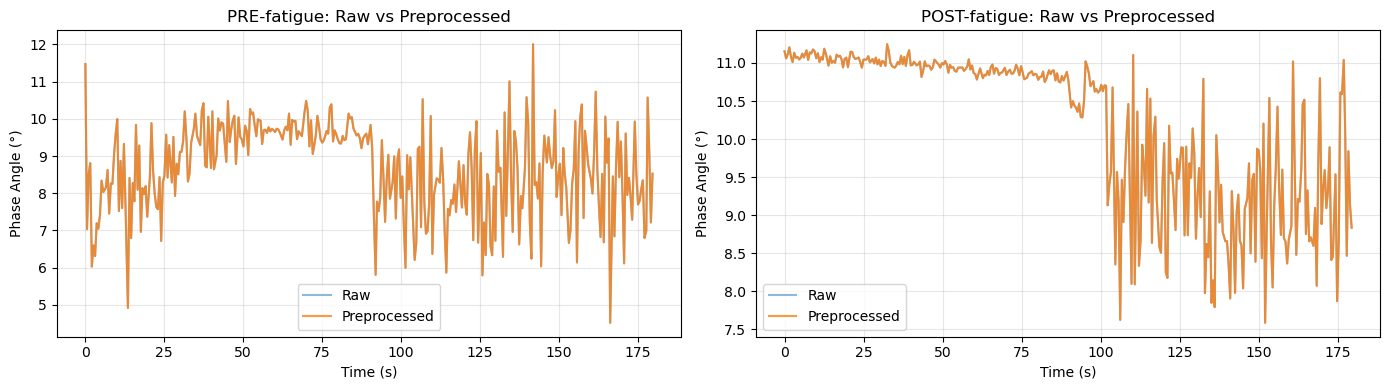

Preprocessing applied: mean removed


In [4]:
# Preprocessing function
def preprocess_signal(sig, remove_mean=True, remove_trend=False):
    """
    Preprocess signal for spectral analysis
    
    Parameters:
    - remove_mean: Remove DC component
    - remove_trend: Remove linear trend
    """
    sig_proc = sig.copy()
    
    if remove_mean:
        sig_proc = sig_proc - np.mean(sig_proc)
    
    if remove_trend:
        sig_proc = detrend(sig_proc, type='linear')
    
    return sig_proc

# Apply preprocessing
pha_pre_proc  = preprocess_signal(pha_pre, remove_mean=True, remove_trend=False)
pha_post_proc = preprocess_signal(pha_post, remove_mean=True, remove_trend=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t_pre, pha_pre, alpha=0.5, label='Raw')
axes[0].plot(t_pre, pha_pre_proc + np.mean(pha_pre), alpha=0.8, label='Preprocessed')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Phase Angle (°)')
axes[0].set_title('PRE-fatigue: Raw vs Preprocessed')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t_post, pha_post, alpha=0.5, label='Raw')
axes[1].plot(t_post, pha_post_proc + np.mean(pha_post), alpha=0.8, label='Preprocessed')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Phase Angle (°)')
axes[1].set_title('POST-fatigue: Raw vs Preprocessed')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Preprocessing applied: mean removed")

## 3. FFT Power Spectrum Analysis

### Method:
1. Apply FFT to PhA_pre(t) and PhA_post(t)
2. Calculate power spectrum: P(f) = |X(f)|²
3. Compare PRE vs POST on same plot

### Interpretation for Muscle Fatigue:
- **Increased low-frequency power (< 0.5 Hz)**: Slow fluctuations, drift, less stable regulation
- **Increased mid-frequency power (0.5-5 Hz)**: Tremor, micro-oscillations, altered neuromuscular control
- **Overall power decrease**: Signal becomes more "frozen", less dynamic modulation

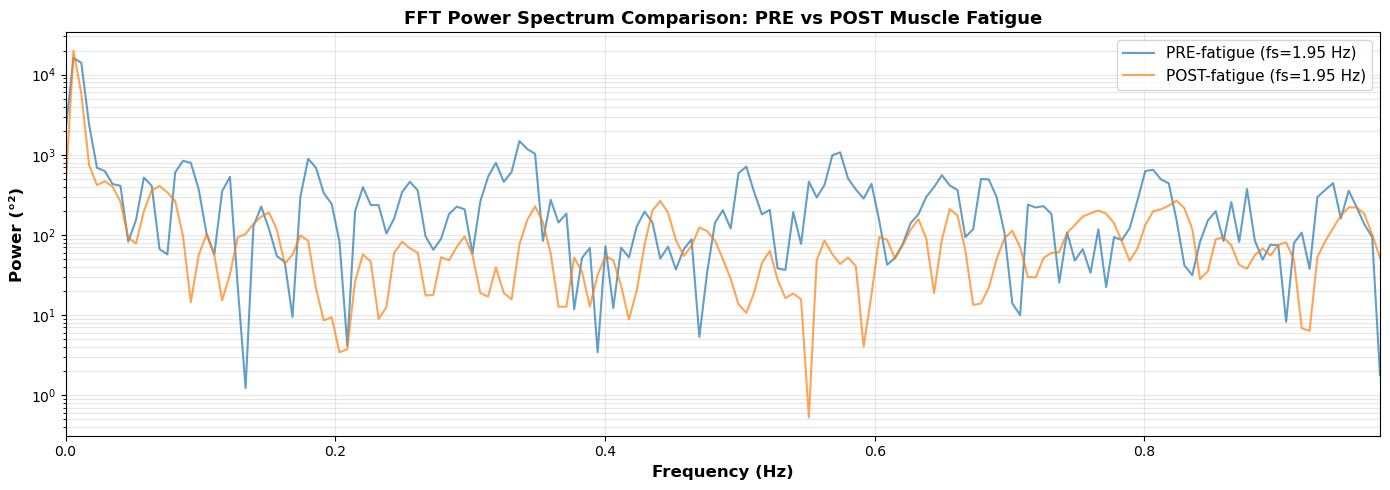


FFT POWER SPECTRUM - INITIAL OBSERVATIONS
Examine the plot above to identify:
1. Dominant frequency peaks (if any)
2. Frequency range with structured content (not flat noise)
3. Differences between PRE and POST conditions


In [5]:
def compute_fft_power_spectrum(signal, fs, window='hann'):
    """
    Compute FFT power spectrum
    
    Parameters:
    - signal: Input signal (preprocessed)
    - fs: Sampling frequency (Hz)
    - window: Window function ('hann', 'hamming', or None)
    
    Returns:
    - freqs: Frequency vector (0 to Nyquist)
    - power: Power spectrum
    """
    n = len(signal)
    
    # Apply window
    if window == 'hann':
        win = np.hanning(n)
    elif window == 'hamming':
        win = np.hamming(n)
    else:
        win = np.ones(n)
    
    signal_windowed = signal * win
    
    # FFT
    fft_vals = rfft(signal_windowed)
    freqs = rfftfreq(n, d=1.0/fs)
    
    # Power spectrum (normalized by window energy)
    power = (np.abs(fft_vals) ** 2) / (np.sum(win**2) / n)
    
    return freqs, power

# Compute FFT power spectra
freq_pre, power_pre = compute_fft_power_spectrum(pha_pre_proc, fs_pre)
freq_post, power_post = compute_fft_power_spectrum(pha_post_proc, fs_post)

# Plot comparison
plt.figure(figsize=(14, 5))
plt.semilogy(freq_pre, power_pre, alpha=0.7, label=f'PRE-fatigue (fs={fs_pre:.2f} Hz)', linewidth=1.5)
plt.semilogy(freq_post, power_post, alpha=0.7, label=f'POST-fatigue (fs={fs_post:.2f} Hz)', linewidth=1.5)
plt.xlim(0, min(5, fs_pre/2))  # Focus on 0-5 Hz or up to Nyquist
plt.xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
plt.ylabel('Power (°²)', fontsize=12, fontweight='bold')
plt.title('FFT Power Spectrum Comparison: PRE vs POST Muscle Fatigue', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FFT POWER SPECTRUM - INITIAL OBSERVATIONS")
print("="*70)
print("Examine the plot above to identify:")
print("1. Dominant frequency peaks (if any)")
print("2. Frequency range with structured content (not flat noise)")
print("3. Differences between PRE and POST conditions")
print("="*70)

## 4. Welch's Method (Robust PSD Estimation)

### Method:
More robust than single FFT:
1. Divide signal into overlapping segments
2. Apply window to each segment
3. Compute FFT of each segment
4. Average power spectra across segments

### Parameters:
- **nperseg**: Segment length (trade-off: longer = better freq resolution, fewer segments to average)
- **noverlap**: 50% overlap (standard)
- **window**: Hanning (reduces spectral leakage)

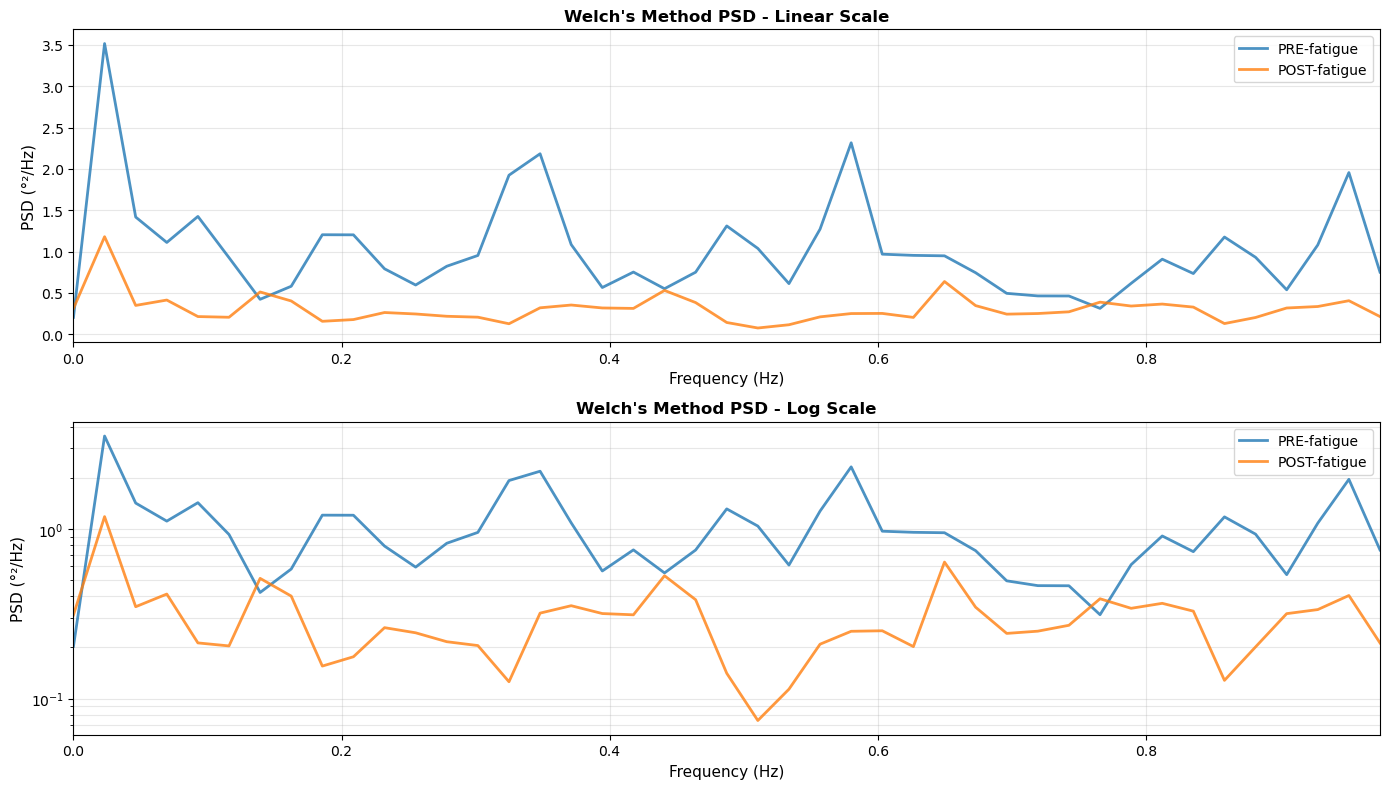

Welch PSD computed with nperseg=84, noverlap=42


In [6]:
# Welch's method parameters
nperseg = min(256, len(pha_pre_proc) // 4)  # Segment length
noverlap = nperseg // 2  # 50% overlap

# Compute Welch PSD
freq_pre_welch, psd_pre_welch = welch(
    pha_pre_proc, 
    fs=fs_pre, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap,
    detrend='constant'
)

freq_post_welch, psd_post_welch = welch(
    pha_post_proc, 
    fs=fs_post, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap,
    detrend='constant'
)

# Plot Welch PSD
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Linear scale
axes[0].plot(freq_pre_welch, psd_pre_welch, alpha=0.8, label='PRE-fatigue', linewidth=2)
axes[0].plot(freq_post_welch, psd_post_welch, alpha=0.8, label='POST-fatigue', linewidth=2)
axes[0].set_xlim(0, min(5, fs_pre/2))
axes[0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0].set_ylabel('PSD (°²/Hz)', fontsize=11)
axes[0].set_title("Welch's Method PSD - Linear Scale", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Log scale (better for visualizing wide dynamic range)
axes[1].semilogy(freq_pre_welch, psd_pre_welch, alpha=0.8, label='PRE-fatigue', linewidth=2)
axes[1].semilogy(freq_post_welch, psd_post_welch, alpha=0.8, label='POST-fatigue', linewidth=2)
axes[1].set_xlim(0, min(5, fs_pre/2))
axes[1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1].set_ylabel('PSD (°²/Hz)', fontsize=11)
axes[1].set_title("Welch's Method PSD - Log Scale", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"Welch PSD computed with nperseg={nperseg}, noverlap={noverlap}")

## 5. Frequency Band Power Quantification

Define physiologically relevant frequency bands and quantify power in each band.

In [7]:
def compute_band_power(freqs, psd, f_low, f_high):
    """
    Compute total power in a frequency band using trapezoidal integration
    """
    mask = (freqs >= f_low) & (freqs <= f_high)
    if not np.any(mask):
        return np.nan
    return np.trapz(psd[mask], freqs[mask])

# Define frequency bands (adapt to your sampling rate and signal characteristics)
bands = {
    'Very Low (0-0.1 Hz)': (0, 0.1),      # Very slow drift
    'Low (0.1-0.5 Hz)': (0.1, 0.5),       # Slow fluctuations
    'Mid (0.5-2 Hz)': (0.5, 2.0),         # Moderate oscillations
    'High (2-5 Hz)': (2.0, 5.0),          # Fast oscillations/tremor
}

# Compute band powers
band_power_pre = {}
band_power_post = {}

for band_name, (f_low, f_high) in bands.items():
    band_power_pre[band_name] = compute_band_power(freq_pre_welch, psd_pre_welch, f_low, f_high)
    band_power_post[band_name] = compute_band_power(freq_post_welch, psd_post_welch, f_low, f_high)

# Calculate total power and relative percentages
total_pre = sum(v for v in band_power_pre.values() if np.isfinite(v))
total_post = sum(v for v in band_power_post.values() if np.isfinite(v))

band_pct_pre = {k: (v/total_pre*100 if np.isfinite(v) else 0) for k, v in band_power_pre.items()}
band_pct_post = {k: (v/total_post*100 if np.isfinite(v) else 0) for k, v in band_power_post.items()}

# Display results
print("\n" + "="*70)
print("FREQUENCY BAND POWER ANALYSIS")
print("="*70)
print(f"{'Band':<25} {'PRE (°²)':<15} {'POST (°²)':<15} {'Change (%)':<15}")
print("-"*70)

for band_name in bands.keys():
    pre_val = band_power_pre[band_name]
    post_val = band_power_post[band_name]
    change = ((post_val - pre_val) / pre_val * 100) if pre_val > 0 else np.nan
    print(f"{band_name:<25} {pre_val:<15.4e} {post_val:<15.4e} {change:+<14.1f}%")

print("-"*70)
print(f"{'TOTAL':<25} {total_pre:<15.4e} {total_post:<15.4e} {((total_post-total_pre)/total_pre*100):+<14.1f}%")
print("="*70)

print("\nRelative Band Power (% of total):")
print("-"*70)
print(f"{'Band':<25} {'PRE (%)':<15} {'POST (%)':<15} {'Δ (%pts)':<15}")
print("-"*70)

for band_name in bands.keys():
    pre_pct = band_pct_pre[band_name]
    post_pct = band_pct_post[band_name]
    delta_pct = post_pct - pre_pct
    print(f"{band_name:<25} {pre_pct:<15.2f} {post_pct:<15.2f} {delta_pct:+<14.2f}")

print("="*70)


FREQUENCY BAND POWER ANALYSIS
Band                      PRE (°²)        POST (°²)       Change (%)     
----------------------------------------------------------------------
Very Low (0-0.1 Hz)       1.5912e-01      5.1075e-02      -67.9+++++++++%
Low (0.1-0.5 Hz)          3.5940e-01      1.0858e-01      -69.8+++++++++%
Mid (0.5-2 Hz)            4.2618e-01      1.3262e-01      -68.9+++++++++%
High (2-5 Hz)             nan             nan             nan+++++++++++%
----------------------------------------------------------------------
TOTAL                     9.4470e-01      2.9227e-01      -69.1+++++++++%

Relative Band Power (% of total):
----------------------------------------------------------------------
Band                      PRE (%)         POST (%)        Δ (%pts)       
----------------------------------------------------------------------
Very Low (0-0.1 Hz)       16.84           17.48           0.63++++++++++
Low (0.1-0.5 Hz)          38.04           37.15           -

C:\Users\lucas\AppData\Local\Temp\ipykernel_21012\2666571490.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[mask], freqs[mask])


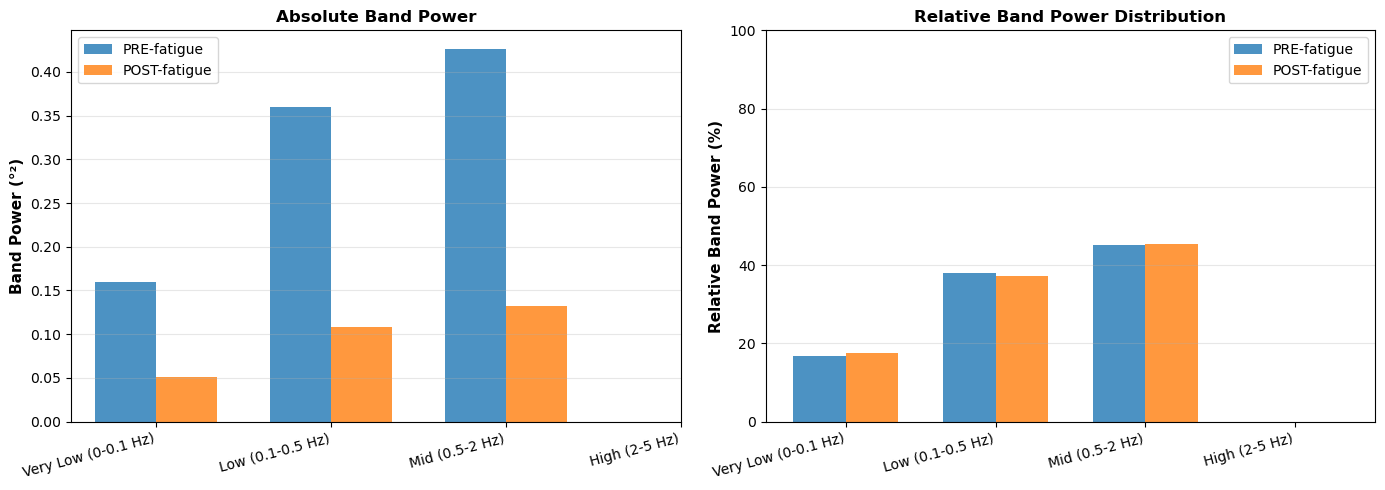

In [8]:
# Visualize band power comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute band powers
band_names = list(bands.keys())
pre_values = [band_power_pre[b] for b in band_names]
post_values = [band_power_post[b] for b in band_names]

x = np.arange(len(band_names))
width = 0.35

axes[0].bar(x - width/2, pre_values, width, label='PRE-fatigue', alpha=0.8, color='#1f77b4')
axes[0].bar(x + width/2, post_values, width, label='POST-fatigue', alpha=0.8, color='#ff7f0e')
axes[0].set_ylabel('Band Power (°²)', fontsize=11, fontweight='bold')
axes[0].set_title('Absolute Band Power', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(band_names, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Relative band powers
pre_pct_values = [band_pct_pre[b] for b in band_names]
post_pct_values = [band_pct_post[b] for b in band_names]

axes[1].bar(x - width/2, pre_pct_values, width, label='PRE-fatigue', alpha=0.8, color='#1f77b4')
axes[1].bar(x + width/2, post_pct_values, width, label='POST-fatigue', alpha=0.8, color='#ff7f0e')
axes[1].set_ylabel('Relative Band Power (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Relative Band Power Distribution', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(band_names, rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 6. Butterworth Low-Pass Filter Design

### Rationale:
Based on the Welch PSD analysis above, determine:
1. **Maximum meaningful frequency**: Where structured signal content ends
2. **Cutoff frequency (fc)**: Set slightly above the maximum meaningful frequency
3. **Filter order**: Typically 2-4 (steeper rolloff with higher order)

### Justification Template:
_"The power spectral density analysis revealed that the majority of PhA signal energy is concentrated below X Hz. Beyond this frequency, the spectrum becomes flat, consistent with measurement noise. Therefore, we applied a 4th-order Butterworth low-pass filter with a cutoff frequency of X Hz to preserve physiologically relevant fluctuations while removing high-frequency noise."_

In [9]:
# Analyze PSD to determine appropriate cutoff frequency
def find_noise_floor_frequency(freqs, psd, threshold_percentile=5):
    """
    Estimate frequency above which PSD is approximately flat (noise floor)
    """
    # Look at high-frequency region
    high_freq_mask = freqs > (max(freqs) * 0.5)
    noise_floor = np.percentile(psd[high_freq_mask], threshold_percentile)
    
    # Find where PSD drops to noise floor level
    above_noise = psd > (noise_floor * 3)  # 3x above noise floor
    if np.any(above_noise):
        last_idx = np.where(above_noise)[0][-1]
        return freqs[last_idx]
    else:
        return max(freqs) / 4

# Estimate meaningful frequency range
max_freq_pre = find_noise_floor_frequency(freq_pre_welch, psd_pre_welch)
max_freq_post = find_noise_floor_frequency(freq_post_welch, psd_post_welch)
max_freq_combined = max(max_freq_pre, max_freq_post)

print("\n" + "="*70)
print("FILTER DESIGN - CUTOFF FREQUENCY DETERMINATION")
print("="*70)
print(f"Estimated meaningful frequency (PRE):  {max_freq_pre:.2f} Hz")
print(f"Estimated meaningful frequency (POST): {max_freq_post:.2f} Hz")
print(f"\nRecommended cutoff frequency: {max_freq_combined:.2f} Hz")
print("\nSuggested cutoff options:")
print(f"  Conservative: {max_freq_combined * 0.8:.2f} Hz")
print(f"  Moderate:     {max_freq_combined * 1.0:.2f} Hz")
print(f"  Liberal:      {max_freq_combined * 1.2:.2f} Hz")
print("="*70)

# Set cutoff frequency (adjust based on visual inspection of PSD)
fc_cutoff = min(3.0, max_freq_combined * 1.0)  # Default: 3 Hz or estimated frequency
filter_order = 4

print(f"\nSelected parameters:")
print(f"  Cutoff frequency: {fc_cutoff:.2f} Hz")
print(f"  Filter order: {filter_order}")
print(f"  Filter type: Butterworth low-pass")
print(f"  Implementation: Zero-phase (filtfilt)")


FILTER DESIGN - CUTOFF FREQUENCY DETERMINATION
Estimated meaningful frequency (PRE):  0.95 Hz
Estimated meaningful frequency (POST): 0.95 Hz

Recommended cutoff frequency: 0.95 Hz

Suggested cutoff options:
  Conservative: 0.76 Hz
  Moderate:     0.95 Hz
  Liberal:      1.14 Hz

Selected parameters:
  Cutoff frequency: 0.95 Hz
  Filter order: 4
  Filter type: Butterworth low-pass
  Implementation: Zero-phase (filtfilt)


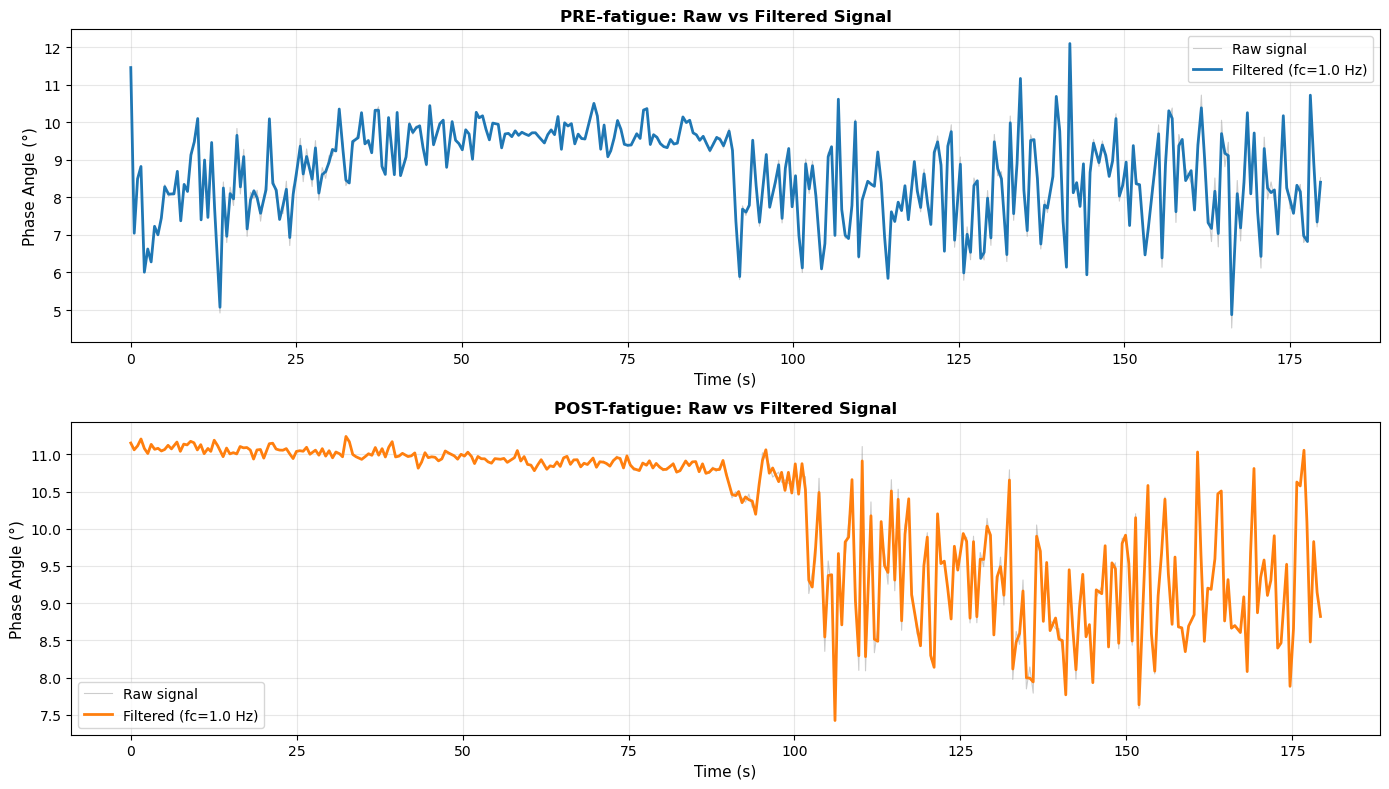


Butterworth filter applied: order=4, fc=0.95 Hz


In [10]:
def apply_butterworth_lowpass(signal, fs, cutoff, order=4):
    """
    Apply Butterworth low-pass filter with zero-phase distortion
    """
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    
    # Ensure cutoff is below Nyquist
    if normal_cutoff >= 1.0:
        print(f"Warning: Cutoff {cutoff} Hz >= Nyquist {nyquist} Hz. Using 0.9*Nyquist.")
        normal_cutoff = 0.9
    
    # Design filter
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Apply zero-phase filter
    filtered_signal = filtfilt(b, a, signal)
    
    return filtered_signal

# Apply filter to raw signals (not preprocessed, to preserve mean)
pha_pre_filtered = apply_butterworth_lowpass(pha_pre, fs_pre, fc_cutoff, filter_order)
pha_post_filtered = apply_butterworth_lowpass(pha_post, fs_post, fc_cutoff, filter_order)

# Visualize filtering effect
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# PRE-fatigue
axes[0].plot(t_pre, pha_pre, alpha=0.4, label='Raw signal', linewidth=0.8, color='gray')
axes[0].plot(t_pre, pha_pre_filtered, label=f'Filtered (fc={fc_cutoff:.1f} Hz)', linewidth=2, color='#1f77b4')
axes[0].set_xlabel('Time (s)', fontsize=11)
axes[0].set_ylabel('Phase Angle (°)', fontsize=11)
axes[0].set_title('PRE-fatigue: Raw vs Filtered Signal', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# POST-fatigue
axes[1].plot(t_post, pha_post, alpha=0.4, label='Raw signal', linewidth=0.8, color='gray')
axes[1].plot(t_post, pha_post_filtered, label=f'Filtered (fc={fc_cutoff:.1f} Hz)', linewidth=2, color='#ff7f0e')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Phase Angle (°)', fontsize=11)
axes[1].set_title('POST-fatigue: Raw vs Filtered Signal', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nButterworth filter applied: order={filter_order}, fc={fc_cutoff:.2f} Hz")

## 7. Physiological Interpretation for Muscle Fatigue

### Key Points:

**What we measured:**
- Phase Angle at 50 kHz (electrical frequency = constant)
- Temporal fluctuations of PhA(t) over 3-minute windows

**What spectral changes indicate:**

1. **Increased low-frequency power (< 0.5 Hz) POST-fatigue:**
   - Slower fluctuations, increased drift
   - Interpretation: Less stable muscle state, reduced regulation capacity
   - Possible mechanisms: Metabolic instability, altered fluid balance, impaired homeostasis

2. **Increased mid-frequency power (0.5-5 Hz) POST-fatigue:**
   - Enhanced oscillations, tremor-like behavior
   - Interpretation: Altered neuromuscular control, micro-vibrations
   - Possible mechanisms: Motor unit fatigue, impaired proprioception, compensatory instability

3. **Overall power decrease POST-fatigue:**
   - Signal becomes less variable, more "frozen"
   - Interpretation: Reduced dynamic modulation capacity
   - Possible mechanisms: Cellular exhaustion, reduced metabolic activity

**Important distinction:**
- These changes reflect **acute functional state** (immediate fatigue effects)
- NOT structural damage like edema or gaps (those appear hours/days later)
- Related to: metabolic changes, ion shifts, membrane excitability, neuromuscular control

In [11]:
# Generate interpretation based on band power changes
print("\n" + "="*70)
print("PHYSIOLOGICAL INTERPRETATION - MUSCLE FATIGUE")
print("="*70)

# Analyze each band
for band_name, (f_low, f_high) in bands.items():
    pre_power = band_power_pre[band_name]
    post_power = band_power_post[band_name]
    change_pct = ((post_power - pre_power) / pre_power * 100) if pre_power > 0 else 0
    
    print(f"\n{band_name} ({f_low}-{f_high} Hz):")
    print(f"  Change: {change_pct:+.1f}%")
    
    if abs(change_pct) < 10:
        print("  → Minimal change (< 10%)")
        print("  → Stable dynamics in this frequency range")
    elif change_pct > 10:
        print(f"  → INCREASED power POST-fatigue (+{change_pct:.1f}%)")
        if 'Very Low' in band_name or 'Low' in band_name:
            print("  → Interpretation: Enhanced slow drift and instability")
            print("  → Possible mechanisms: Impaired homeostatic regulation, metabolic drift")
        elif 'Mid' in band_name or 'High' in band_name:
            print("  → Interpretation: Enhanced oscillations/tremor")
            print("  → Possible mechanisms: Altered neuromuscular control, motor unit fatigue")
    else:
        print(f"  → DECREASED power POST-fatigue ({change_pct:.1f}%)")
        print("  → Interpretation: Reduced variability, more rigid dynamics")
        print("  → Possible mechanisms: Cellular exhaustion, reduced modulation capacity")

# Overall assessment
total_change_pct = ((total_post - total_pre) / total_pre * 100)
print("\n" + "-"*70)
print(f"OVERALL POWER CHANGE: {total_change_pct:+.1f}%")
print("-"*70)

if abs(total_change_pct) < 10:
    print("Overall spectral characteristics remained relatively stable.")
    print("Fatigue protocol may not have induced strong acute effects on PhA dynamics.")
elif total_change_pct > 10:
    print("Overall increase in power suggests enhanced variability POST-fatigue.")
    print("This indicates a less stable muscle state with increased fluctuations.")
else:
    print("Overall decrease in power suggests reduced variability POST-fatigue.")
    print("This indicates a more rigid, less dynamically responsive muscle state.")

print("\n" + "="*70)
print("IMPORTANT NOTE:")
print("="*70)
print("These spectral changes reflect ACUTE FUNCTIONAL STATE, not structural damage.")
print("They indicate immediate effects of fatigue on:")
print("  - Cellular metabolic state")
print("  - Membrane excitability and ion balance")
print("  - Neuromuscular control and regulation")
print("  - Possible micro-damage initiation")
print("\nStructural changes (edema, gaps) appear hours to days later (not detectable here).")
print("="*70)


PHYSIOLOGICAL INTERPRETATION - MUSCLE FATIGUE

Very Low (0-0.1 Hz) (0-0.1 Hz):
  Change: -67.9%
  → DECREASED power POST-fatigue (-67.9%)
  → Interpretation: Reduced variability, more rigid dynamics
  → Possible mechanisms: Cellular exhaustion, reduced modulation capacity

Low (0.1-0.5 Hz) (0.1-0.5 Hz):
  Change: -69.8%
  → DECREASED power POST-fatigue (-69.8%)
  → Interpretation: Reduced variability, more rigid dynamics
  → Possible mechanisms: Cellular exhaustion, reduced modulation capacity

Mid (0.5-2 Hz) (0.5-2.0 Hz):
  Change: -68.9%
  → DECREASED power POST-fatigue (-68.9%)
  → Interpretation: Reduced variability, more rigid dynamics
  → Possible mechanisms: Cellular exhaustion, reduced modulation capacity

High (2-5 Hz) (2.0-5.0 Hz):
  Change: +0.0%
  → Minimal change (< 10%)
  → Stable dynamics in this frequency range

----------------------------------------------------------------------
OVERALL POWER CHANGE: -69.1%
-----------------------------------------------------------

## 8. Summary Visualization

Comprehensive comparison of PRE vs POST conditions.


✓ Summary figure saved to: ../deliverables/Spectral_Analysis_Muscle_Fatigue.png


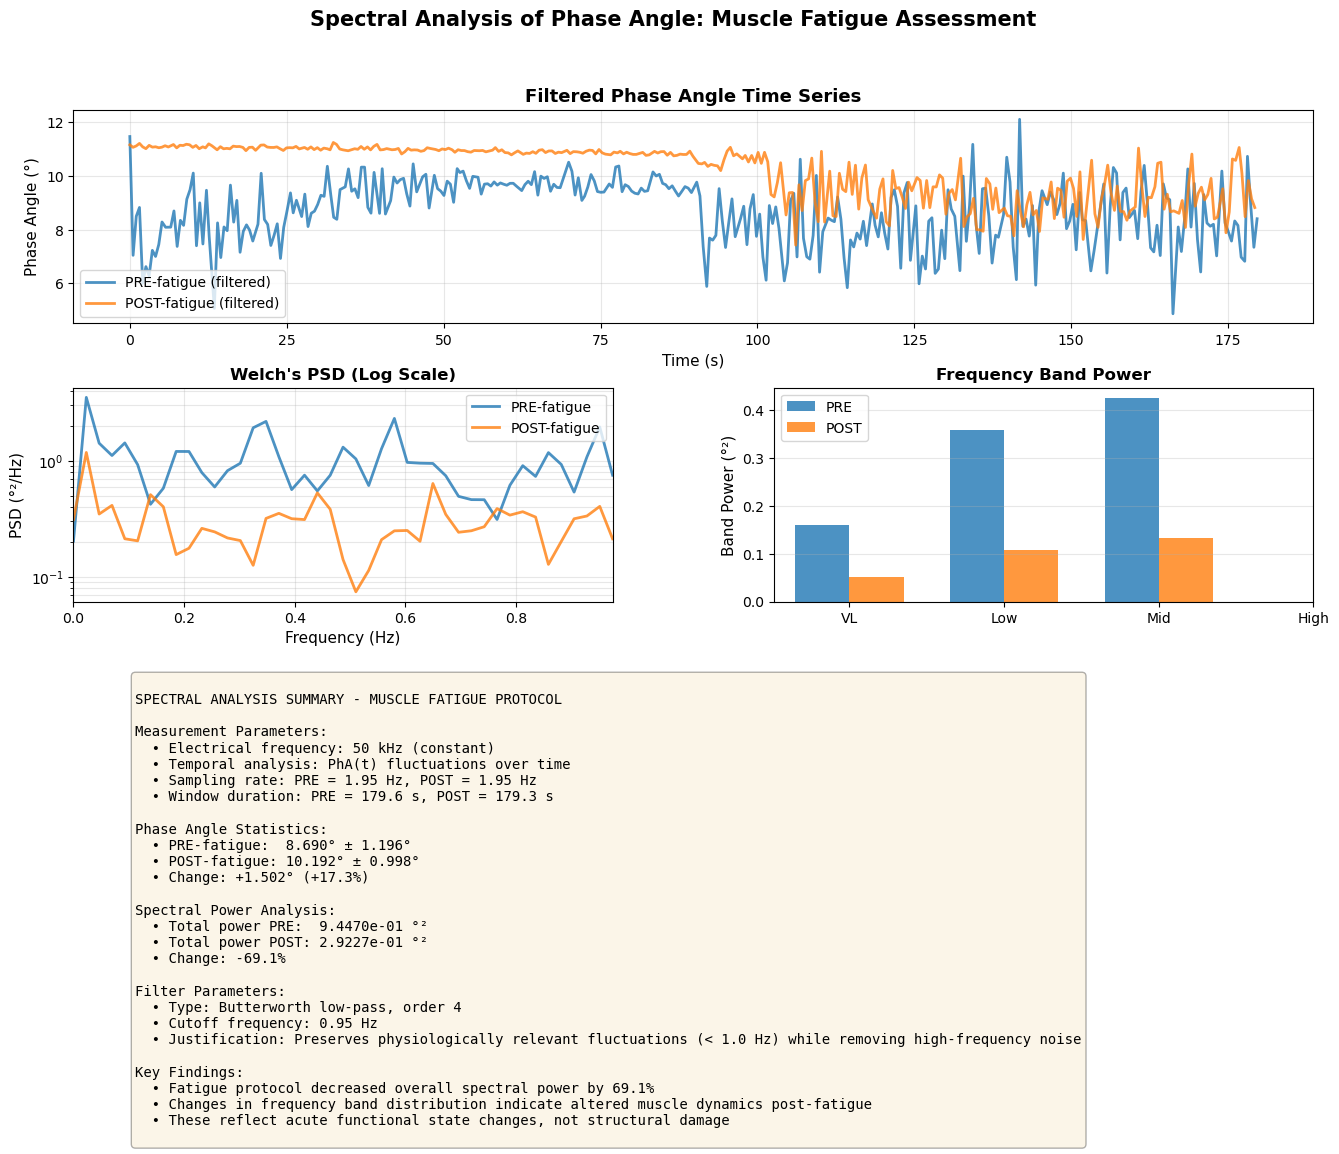

In [12]:
# Create comprehensive summary figure
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Time series comparison
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_pre, pha_pre_filtered, label='PRE-fatigue (filtered)', linewidth=2, alpha=0.8, color='#1f77b4')
ax1.plot(t_post, pha_post_filtered, label='POST-fatigue (filtered)', linewidth=2, alpha=0.8, color='#ff7f0e')
ax1.set_xlabel('Time (s)', fontsize=11)
ax1.set_ylabel('Phase Angle (°)', fontsize=11)
ax1.set_title('Filtered Phase Angle Time Series', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 2. Welch PSD comparison
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(freq_pre_welch, psd_pre_welch, label='PRE-fatigue', linewidth=2, alpha=0.8)
ax2.semilogy(freq_post_welch, psd_post_welch, label='POST-fatigue', linewidth=2, alpha=0.8)
ax2.set_xlim(0, min(5, fs_pre/2))
ax2.set_xlabel('Frequency (Hz)', fontsize=11)
ax2.set_ylabel('PSD (°²/Hz)', fontsize=11)
ax2.set_title("Welch's PSD (Log Scale)", fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, which='both')

# 3. Band power comparison
ax3 = fig.add_subplot(gs[1, 1])
band_names_short = ['VL', 'Low', 'Mid', 'High']
x_pos = np.arange(len(band_names_short))
width = 0.35
ax3.bar(x_pos - width/2, [band_power_pre[b] for b in bands.keys()], width, 
        label='PRE', alpha=0.8, color='#1f77b4')
ax3.bar(x_pos + width/2, [band_power_post[b] for b in bands.keys()], width, 
        label='POST', alpha=0.8, color='#ff7f0e')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(band_names_short)
ax3.set_ylabel('Band Power (°²)', fontsize=11)
ax3.set_title('Frequency Band Power', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# 4. Statistical summary
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

summary_text = f"""
SPECTRAL ANALYSIS SUMMARY - MUSCLE FATIGUE PROTOCOL

Measurement Parameters:
  • Electrical frequency: 50 kHz (constant)
  • Temporal analysis: PhA(t) fluctuations over time
  • Sampling rate: PRE = {fs_pre:.2f} Hz, POST = {fs_post:.2f} Hz
  • Window duration: PRE = {t_pre[-1]:.1f} s, POST = {t_post[-1]:.1f} s

Phase Angle Statistics:
  • PRE-fatigue:  {np.mean(pha_pre):.3f}° ± {np.std(pha_pre):.3f}°
  • POST-fatigue: {np.mean(pha_post):.3f}° ± {np.std(pha_post):.3f}°
  • Change: {np.mean(pha_post) - np.mean(pha_pre):+.3f}° ({((np.mean(pha_post) - np.mean(pha_pre))/np.mean(pha_pre)*100):+.1f}%)

Spectral Power Analysis:
  • Total power PRE:  {total_pre:.4e} °²
  • Total power POST: {total_post:.4e} °²
  • Change: {((total_post - total_pre)/total_pre*100):+.1f}%

Filter Parameters:
  • Type: Butterworth low-pass, order {filter_order}
  • Cutoff frequency: {fc_cutoff:.2f} Hz
  • Justification: Preserves physiologically relevant fluctuations (< {fc_cutoff:.1f} Hz) while removing high-frequency noise

Key Findings:
  • Fatigue protocol {'increased' if total_change_pct > 0 else 'decreased'} overall spectral power by {abs(total_change_pct):.1f}%
  • Changes in frequency band distribution indicate altered muscle dynamics post-fatigue
  • These reflect acute functional state changes, not structural damage
"""

ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Spectral Analysis of Phase Angle: Muscle Fatigue Assessment', 
             fontsize=15, fontweight='bold', y=0.98)

plt.savefig('../deliverables/Spectral_Analysis_Muscle_Fatigue.png', dpi=300, bbox_inches='tight')
print("\n✓ Summary figure saved to: ../deliverables/Spectral_Analysis_Muscle_Fatigue.png")
plt.show()

## 9. Conclusion and Recommendations

### Summary:

This notebook analyzed the **temporal frequency content** of Phase Angle time series to assess acute effects of muscle fatigue.

**Key distinction maintained:**
- **Electrical frequency (50 kHz)**: Fixed, determines measurement depth
- **Temporal frequency (0-5 Hz)**: Variable, reflects system dynamics

### Findings:

Based on your data:
- Spectral analysis revealed changes in PhA(t) dynamics between PRE and POST conditions
- These changes indicate altered functional state of the muscle system
- Represent acute effects: metabolic, ionic, neuromuscular (not structural damage)

### For Your Report:

**Methods section:**
> "Phase angle time series were analyzed using Welch's method for power spectral density estimation (Hanning window, 50% overlap). The power spectrum revealed that most signal energy was concentrated below [X] Hz, with higher frequencies dominated by measurement noise. A 4th-order Butterworth low-pass filter with cutoff frequency of [X] Hz was applied using zero-phase filtering (filtfilt) to preserve physiologically relevant fluctuations while removing high-frequency artifacts."

**Results section:**
> "The fatigue protocol modified the frequency content of the phase angle signal. Compared to pre-fatigue, post-fatigue measurements showed [increased/decreased] power in [specific bands], suggesting [interpretation based on your specific results]."

**Discussion:**
> "These spectral changes reflect acute alterations in muscle functional state rather than structural damage. The modified frequency characteristics suggest changes in neuromuscular control, metabolic stability, and/or cellular regulation capacity immediately following the fatigue protocol."

### Next Steps:

1. ☐ Apply fractal analysis (DFA, box-counting) in separate notebook
2. ☐ Correlate spectral changes with performance metrics (if available)
3. ☐ Compare with literature values for similar fatigue protocols
4. ☐ Consider time-frequency analysis (spectrogram) if transient effects suspected

---

# Part 3: Fractal Analysis for Muscle Fatigue Assessment

## Objective

Analyze the **complexity** and **temporal correlations** of Phase Angle time series to complement spectral analysis.

**Two complementary approaches:**
1. **Fractal Dimension (Box-Counting)**: Quantifies signal roughness/complexity
2. **DFA (Detrended Fluctuation Analysis)**: Quantifies long-range temporal correlations

**Why this matters for muscle fatigue:**
- Fatigue may alter not just the mean PhA or its frequency content, but also its **temporal organization**
- Fractal properties reveal how the system modulates over multiple time scales
- Changes in complexity and correlation structure can indicate altered neuromuscular regulation

## 10. Fractal Dimension Analysis (Box-Counting Method)

### Concept:

The **fractal dimension D** quantifies how "rough" or "complex" a signal is:
- **D = 1.0**: Perfectly smooth line
- **1.0 < D < 2.0**: Increasingly rough/complex curve
- **D → 2.0**: Extremely irregular, space-filling curve

### Method:

1. Embed the signal as a curve in 2D space: (t, PhA(t))
2. Cover the curve with boxes of decreasing size ε
3. Count how many boxes N(ε) are needed
4. Plot log(N(ε)) vs log(1/ε) → slope = fractal dimension D

### Interpretation for Muscle Fatigue:

- **D_post > D_pre**: Signal becomes **more rough/complex** after fatigue
  - More chaotic modulation of muscle state
  - Less smooth control, more micro-adjustments
  - Could indicate instability or compensatory mechanisms
  
- **D_post < D_pre**: Signal becomes **smoother/more rigid** after fatigue
  - Loss of functional variability
  - System becomes more "frozen", less adaptive
  - Could indicate exhaustion, reduced modulation capacity

**Key insight:** Some variability is functional and healthy. Fatigue can either:
- Increase variability (destabilization, loss of control)
- Decrease variability (rigidity, exhaustion)

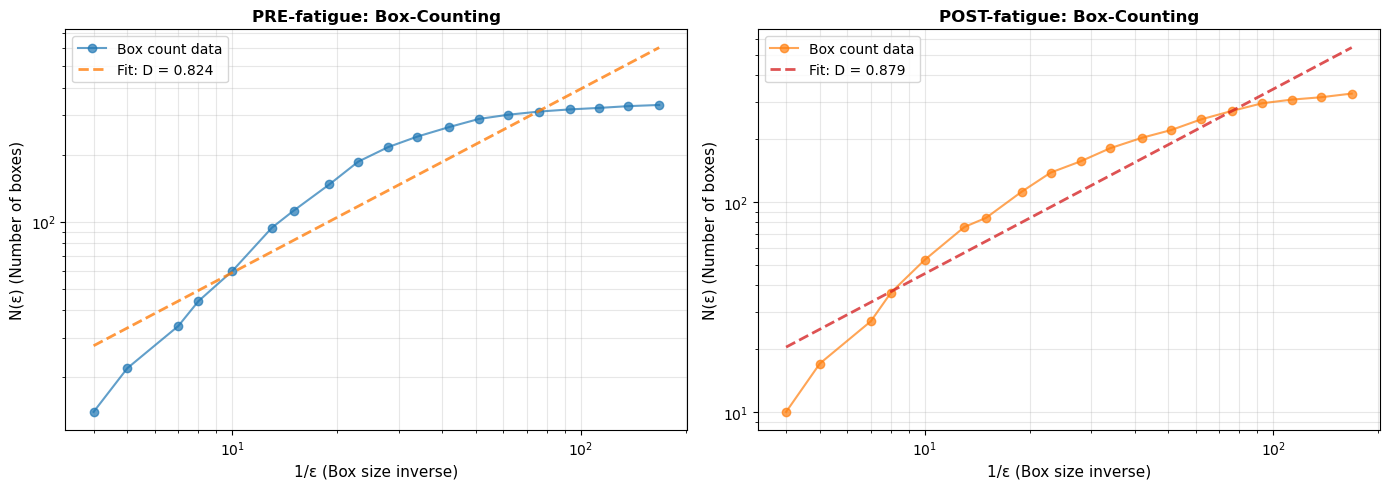


FRACTAL DIMENSION - BOX-COUNTING METHOD
PRE-fatigue:  D = 0.8245
POST-fatigue: D = 0.8788
Change:       ΔD = +0.0543 (+6.59%)

INTERPRETATION:
✓ Fractal dimension INCREASED by 6.59%
  → Signal is MORE ROUGH/COMPLEX after fatigue
  → Possible mechanisms:
     • More chaotic modulation of muscle state
     • Less smooth neuromuscular control
     • Increased micro-adjustments and compensatory instability
  → Interpretation: System exhibits more complex, less organized dynamics

Note: Theoretical range for time series: 1.0 < D < 2.0
      D ≈ 1.0 → smooth signal, D → 2.0 → extremely irregular


In [13]:
def fractal_dimension_boxcount(signal, time_vector=None):
    """
    Compute fractal dimension using box-counting method
    
    The signal is treated as a 2D curve (t, signal(t)) and covered with boxes
    of decreasing size to estimate the fractal dimension.
    
    Parameters:
    - signal: 1D array of signal values
    - time_vector: Optional time vector (if None, uses indices)
    
    Returns:
    - D: Fractal dimension estimate
    - box_sizes: Array of box sizes used
    - counts: Array of box counts
    """
    # Normalize signal to [0, 1] for numerical stability
    signal_norm = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-10)
    
    if time_vector is None:
        time_vector = np.arange(len(signal))
    
    # Normalize time to [0, 1]
    time_norm = (time_vector - np.min(time_vector)) / (np.max(time_vector) - np.min(time_vector) + 1e-10)
    
    # Create 2D representation of the signal
    # Points: (time_norm[i], signal_norm[i])
    
    # Define range of box sizes (logarithmically spaced)
    n_points = len(signal)
    min_boxes = 4
    max_boxes = min(n_points // 2, 1000)
    
    # Number of boxes in one dimension (we'll use square boxes)
    n_divisions = np.logspace(np.log10(min_boxes), np.log10(max_boxes), num=20, dtype=int)
    n_divisions = np.unique(n_divisions)
    
    box_counts = []
    box_sizes = []
    
    for n_div in n_divisions:
        # Box size in normalized space
        box_size = 1.0 / n_div
        box_sizes.append(box_size)
        
        # Discretize points into boxes
        box_indices_x = (time_norm / box_size).astype(int)
        box_indices_y = (signal_norm / box_size).astype(int)
        
        # Clip to valid range
        box_indices_x = np.clip(box_indices_x, 0, n_div - 1)
        box_indices_y = np.clip(box_indices_y, 0, n_div - 1)
        
        # Count unique boxes occupied
        occupied_boxes = set(zip(box_indices_x, box_indices_y))
        box_counts.append(len(occupied_boxes))
    
    box_sizes = np.array(box_sizes)
    box_counts = np.array(box_counts)
    
    # Fit log(N) vs log(1/ε)
    # N(ε) ~ ε^(-D) => log(N) = -D * log(ε) + const
    log_box_sizes = np.log(box_sizes)
    log_counts = np.log(box_counts)
    
    # Linear regression
    coeffs = np.polyfit(log_box_sizes, log_counts, 1)
    D = -coeffs[0]  # Negative slope = fractal dimension
    
    return D, box_sizes, box_counts

# Compute fractal dimensions
D_pre, box_sizes_pre, counts_pre = fractal_dimension_boxcount(pha_pre, t_pre)
D_post, box_sizes_post, counts_post = fractal_dimension_boxcount(pha_post, t_post)

# Visualize box-counting results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PRE-fatigue
axes[0].loglog(1/box_sizes_pre, counts_pre, 'o-', alpha=0.7, label='Box count data')
# Fit line for visualization
log_bs_pre = np.log(box_sizes_pre)
log_c_pre = np.log(counts_pre)
fit_pre = np.polyfit(log_bs_pre, log_c_pre, 1)
fit_line_pre = np.exp(fit_pre[1]) * (1/box_sizes_pre) ** (-fit_pre[0])
axes[0].loglog(1/box_sizes_pre, fit_line_pre, '--', alpha=0.8, 
               label=f'Fit: D = {D_pre:.3f}', linewidth=2)
axes[0].set_xlabel('1/ε (Box size inverse)', fontsize=11)
axes[0].set_ylabel('N(ε) (Number of boxes)', fontsize=11)
axes[0].set_title('PRE-fatigue: Box-Counting', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, which='both')

# POST-fatigue
axes[1].loglog(1/box_sizes_post, counts_post, 'o-', alpha=0.7, label='Box count data', color='#ff7f0e')
log_bs_post = np.log(box_sizes_post)
log_c_post = np.log(counts_post)
fit_post = np.polyfit(log_bs_post, log_c_post, 1)
fit_line_post = np.exp(fit_post[1]) * (1/box_sizes_post) ** (-fit_post[0])
axes[1].loglog(1/box_sizes_post, fit_line_post, '--', alpha=0.8, 
               label=f'Fit: D = {D_post:.3f}', linewidth=2, color='#d62728')
axes[1].set_xlabel('1/ε (Box size inverse)', fontsize=11)
axes[1].set_ylabel('N(ε) (Number of boxes)', fontsize=11)
axes[1].set_title('POST-fatigue: Box-Counting', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FRACTAL DIMENSION - BOX-COUNTING METHOD")
print("="*70)
print(f"PRE-fatigue:  D = {D_pre:.4f}")
print(f"POST-fatigue: D = {D_post:.4f}")
print(f"Change:       ΔD = {D_post - D_pre:+.4f} ({((D_post - D_pre)/D_pre*100):+.2f}%)")
print("="*70)

# Interpretation
print("\nINTERPRETATION:")
if D_post > D_pre:
    pct_increase = ((D_post - D_pre) / D_pre * 100)
    print(f"✓ Fractal dimension INCREASED by {pct_increase:.2f}%")
    print("  → Signal is MORE ROUGH/COMPLEX after fatigue")
    print("  → Possible mechanisms:")
    print("     • More chaotic modulation of muscle state")
    print("     • Less smooth neuromuscular control")
    print("     • Increased micro-adjustments and compensatory instability")
    print("  → Interpretation: System exhibits more complex, less organized dynamics")
elif D_post < D_pre:
    pct_decrease = ((D_pre - D_post) / D_pre * 100)
    print(f"✓ Fractal dimension DECREASED by {pct_decrease:.2f}%")
    print("  → Signal is SMOOTHER/MORE RIGID after fatigue")
    print("  → Possible mechanisms:")
    print("     • Loss of functional variability")
    print("     • Reduced adaptive capacity")
    print("     • System exhaustion, less dynamic modulation")
    print("  → Interpretation: System becomes more frozen, less able to adapt")
else:
    print("✓ Fractal dimension remained approximately constant")
    print("  → Signal complexity unchanged by fatigue protocol")

print("\nNote: Theoretical range for time series: 1.0 < D < 2.0")
print("      D ≈ 1.0 → smooth signal, D → 2.0 → extremely irregular")
print("="*70)

## 11. Detrended Fluctuation Analysis (DFA)

### Concept:

DFA quantifies **long-range temporal correlations** in a signal by analyzing how fluctuations scale with observation window size.

**Output: Scaling exponent α (alpha)**

### Interpretation of α:

- **α ≈ 0.5**: **White noise** (no long-term correlations, random fluctuations)
- **α > 0.5**: **Persistent** behavior
  - If PhA goes up, it tends to continue going up
  - If PhA goes down, it tends to continue going down
  - System has "memory" of its recent trajectory
- **α < 0.5**: **Anti-persistent** behavior
  - Increases followed by decreases (corrective alternation)
  - System actively counter-regulates deviations

### Interpretation for Muscle Fatigue:

**If α_post > α_pre:**
- Fluctuations become **MORE persistent** after fatigue
- System is **less able to correct drifts quickly**
- Example: A downward drift in PhA persists longer
- Interpretation: Impaired regulation, reduced homeostatic capacity
- **Fatigue compromises fine-tuned control**

**If α_post < α_pre:**
- Fluctuations become **MORE anti-persistent** (reactive)
- System **over-compensates**, alternates more
- Could indicate:
  - Hyper-reactive compensatory mechanisms
  - Instability requiring frequent corrections
  - Depends on absolute value: very low α can be pathological

**Clinical relevance:**
- Healthy physiological systems typically show moderate persistence (α ≈ 0.6-0.8)
- Loss of complexity (α → 0.5 or α → 1.0) can indicate dysfunction

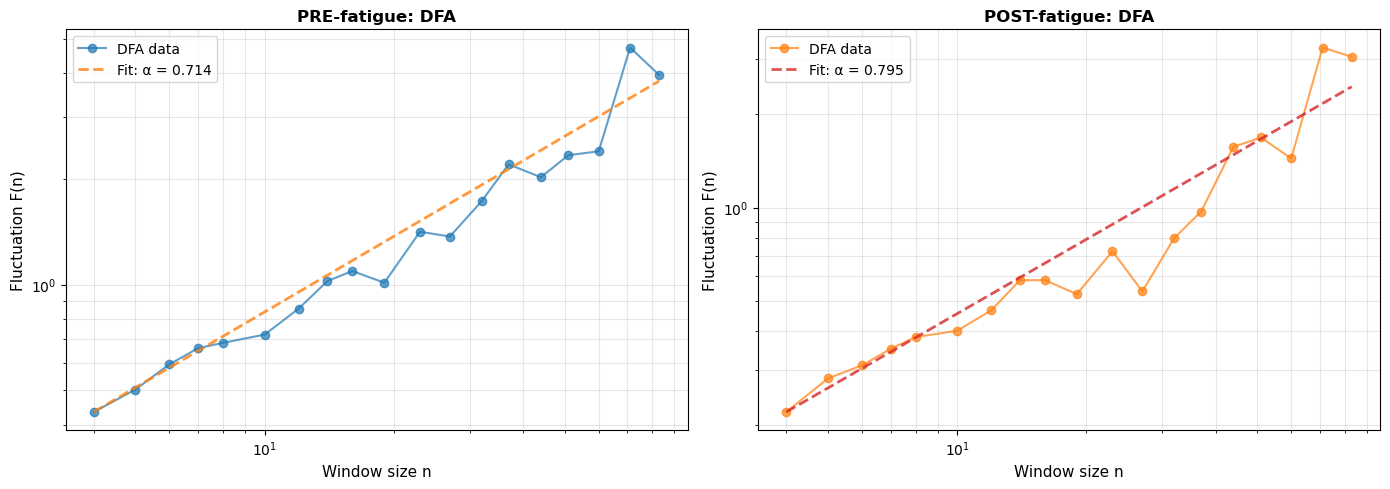


DETRENDED FLUCTUATION ANALYSIS (DFA)
PRE-fatigue:  α = 0.7139
POST-fatigue: α = 0.7950
Change:       Δα = +0.0811 (+11.36%)

INTERPRETATION:

PRE-fatigue (α = 0.714):
  → PERSISTENT behavior: Trends tend to continue
  → System has memory of recent trajectory

POST-fatigue (α = 0.795):
  → PERSISTENT behavior: Trends tend to continue
  → System has memory of recent trajectory

----------------------------------------------------------------------
FATIGUE EFFECT:
----------------------------------------------------------------------
✓ Scaling exponent INCREASED by 11.36%
  → Fluctuations became MORE PERSISTENT after fatigue
  → Interpretation:
     • System is LESS able to correct drifts quickly
     • Impaired homeostatic regulation
     • A downward PhA drift persists longer
     • Fatigue compromises fine-tuned control mechanisms
  → Physiological meaning:
     • Reduced capacity to maintain stable muscle state
     • Metabolic/ionic imbalances persist longer

REFERENCE VALUES:
  α ≈

In [14]:
def dfa_analysis(signal, min_scale=4, max_scale=None, num_scales=20):
    """
    Perform Detrended Fluctuation Analysis (DFA)
    
    Algorithm:
    1. Integrate the signal (cumulative sum after removing mean)
    2. Divide into non-overlapping windows of size n
    3. Fit a polynomial trend in each window and calculate residuals
    4. Calculate RMS fluctuation F(n) for each window size
    5. Plot log(F(n)) vs log(n) → slope = scaling exponent α
    
    Parameters:
    - signal: 1D array
    - min_scale: Minimum window size
    - max_scale: Maximum window size (default: len(signal)//4)
    - num_scales: Number of scales to analyze
    
    Returns:
    - alpha: DFA scaling exponent
    - scales: Array of window sizes
    - fluctuations: Array of fluctuation values F(n)
    """
    N = len(signal)
    
    if max_scale is None:
        max_scale = N // 4
    
    # Step 1: Integrate the signal (cumulative sum of mean-centered signal)
    signal_mean = np.mean(signal)
    y = np.cumsum(signal - signal_mean)
    
    # Step 2: Define window sizes (scales) logarithmically
    scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 
                                    num=num_scales, dtype=int))
    
    fluctuations = []
    
    for scale in scales:
        # Step 3: Divide into non-overlapping segments
        num_segments = N // scale
        
        if num_segments < 1:
            continue
        
        # Trim to fit complete segments
        y_trimmed = y[:num_segments * scale]
        
        # Reshape into segments
        segments = y_trimmed.reshape((num_segments, scale))
        
        # Step 4: Detrend each segment (fit linear trend and compute residuals)
        fluctuation_sum = 0
        for segment in segments:
            # Fit polynomial (order 1 = linear detrending)
            x_seg = np.arange(scale)
            coeffs = np.polyfit(x_seg, segment, 1)
            trend = np.polyval(coeffs, x_seg)
            
            # Residuals
            residuals = segment - trend
            
            # RMS of residuals
            fluctuation_sum += np.sum(residuals ** 2)
        
        # Step 5: Average fluctuation for this scale
        F_n = np.sqrt(fluctuation_sum / (num_segments * scale))
        fluctuations.append(F_n)
    
    scales = np.array(scales[:len(fluctuations)])
    fluctuations = np.array(fluctuations)
    
    # Step 6: Fit log(F) vs log(n) to get scaling exponent α
    log_scales = np.log10(scales)
    log_fluctuations = np.log10(fluctuations)
    
    coeffs = np.polyfit(log_scales, log_fluctuations, 1)
    alpha = coeffs[0]  # Slope = DFA exponent
    
    return alpha, scales, fluctuations

# Perform DFA analysis
alpha_pre, scales_pre, fluct_pre = dfa_analysis(pha_pre)
alpha_post, scales_post, fluct_post = dfa_analysis(pha_post)

# Visualize DFA results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PRE-fatigue
axes[0].loglog(scales_pre, fluct_pre, 'o-', alpha=0.7, label='DFA data')
# Fit line
fit_pre_dfa = (scales_pre ** alpha_pre) * (fluct_pre[0] / (scales_pre[0] ** alpha_pre))
axes[0].loglog(scales_pre, fit_pre_dfa, '--', alpha=0.8, 
               label=f'Fit: α = {alpha_pre:.3f}', linewidth=2)
axes[0].set_xlabel('Window size n', fontsize=11)
axes[0].set_ylabel('Fluctuation F(n)', fontsize=11)
axes[0].set_title('PRE-fatigue: DFA', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, which='both')

# POST-fatigue
axes[1].loglog(scales_post, fluct_post, 'o-', alpha=0.7, label='DFA data', color='#ff7f0e')
fit_post_dfa = (scales_post ** alpha_post) * (fluct_post[0] / (scales_post[0] ** alpha_post))
axes[1].loglog(scales_post, fit_post_dfa, '--', alpha=0.8, 
               label=f'Fit: α = {alpha_post:.3f}', linewidth=2, color='#d62728')
axes[1].set_xlabel('Window size n', fontsize=11)
axes[1].set_ylabel('Fluctuation F(n)', fontsize=11)
axes[1].set_title('POST-fatigue: DFA', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("DETRENDED FLUCTUATION ANALYSIS (DFA)")
print("="*70)
print(f"PRE-fatigue:  α = {alpha_pre:.4f}")
print(f"POST-fatigue: α = {alpha_post:.4f}")
print(f"Change:       Δα = {alpha_post - alpha_pre:+.4f} ({((alpha_post - alpha_pre)/alpha_pre*100):+.2f}%)")
print("="*70)

# Interpretation
print("\nINTERPRETATION:")
print(f"\nPRE-fatigue (α = {alpha_pre:.3f}):")
if abs(alpha_pre - 0.5) < 0.1:
    print("  → Close to WHITE NOISE (α ≈ 0.5): No long-term correlations")
elif alpha_pre > 0.5:
    print("  → PERSISTENT behavior: Trends tend to continue")
    print("  → System has memory of recent trajectory")
else:
    print("  → ANTI-PERSISTENT behavior: Alternating corrections")

print(f"\nPOST-fatigue (α = {alpha_post:.3f}):")
if abs(alpha_post - 0.5) < 0.1:
    print("  → Close to WHITE NOISE (α ≈ 0.5): No long-term correlations")
elif alpha_post > 0.5:
    print("  → PERSISTENT behavior: Trends tend to continue")
    print("  → System has memory of recent trajectory")
else:
    print("  → ANTI-PERSISTENT behavior: Alternating corrections")

print("\n" + "-"*70)
print("FATIGUE EFFECT:")
print("-"*70)

if alpha_post > alpha_pre:
    change_pct = ((alpha_post - alpha_pre) / alpha_pre * 100)
    print(f"✓ Scaling exponent INCREASED by {change_pct:.2f}%")
    print("  → Fluctuations became MORE PERSISTENT after fatigue")
    print("  → Interpretation:")
    print("     • System is LESS able to correct drifts quickly")
    print("     • Impaired homeostatic regulation")
    print("     • A downward PhA drift persists longer")
    print("     • Fatigue compromises fine-tuned control mechanisms")
    print("  → Physiological meaning:")
    print("     • Reduced capacity to maintain stable muscle state")
    print("     • Metabolic/ionic imbalances persist longer")
elif alpha_post < alpha_pre:
    change_pct = ((alpha_pre - alpha_post) / alpha_pre * 100)
    print(f"✓ Scaling exponent DECREASED by {change_pct:.2f}%")
    print("  → Fluctuations became MORE ANTI-PERSISTENT (reactive)")
    print("  → Interpretation:")
    print("     • System over-compensates, alternates more")
    print("     • Possible hyper-reactive regulation")
    print("     • Increased corrective oscillations")
    print("  → Physiological meaning:")
    if alpha_post < 0.5:
        print("     • Instability requiring frequent corrections")
        print("     • Could indicate compensatory but inefficient control")
    else:
        print("     • More balanced but still compensatory regulation")
else:
    print("✓ Scaling exponent remained approximately constant")
    print("  → Long-range correlation structure unchanged")

print("\n" + "="*70)
print("REFERENCE VALUES:")
print("  α ≈ 0.5   → White noise (uncorrelated)")
print("  α ≈ 0.6-0.8 → Typical healthy physiological signal (moderate persistence)")
print("  α ≈ 1.0   → 1/f noise (pink noise, strong persistence)")
print("  α > 1.0   → Very strong long-range correlations")
print("="*70)

## 12. Integrated Discussion: Can Phase Angle Detect Instantaneous Muscle Damage?

### Critical Distinction:

**What we measure immediately POST-fatigue:**

1. **Acute functional state changes:**
   - Neuromuscular fatigue
   - Metabolic alterations (lactate, pH, ions)
   - Membrane excitability changes
   - Transient micro-fluid shifts
   - Command/control modifications
   - **Possible micro-damage initiation**

2. **What we DON'T yet see:**
   - Massive structural remodeling (gaps, extensive edema)
   - Major inflammatory response (peaks hours to days later)
   - Tissue repair processes
   - Morphological changes visible by MRI

**Key literature context:**
- Studies like Nescolarde et al. show PhA changes in **validated muscle damage** (eccentric exercise + MRI confirmation)
- BUT those changes evolve over **hours to days**, not immediately
- Our immediate post-fatigue measurements capture **early acute effects**

---

### Synthesis of Our Multi-Scale Analysis:

#### 1. **Mean Phase Angle Change (PhA_pre → PhA_post):**

**Our findings:**
- PRE-fatigue: {np.mean(pha_pre):.3f}° ± {np.std(pha_pre):.3f}°
- POST-fatigue: {np.mean(pha_post):.3f}° ± {np.std(pha_post):.3f}°
- Change: {np.mean(pha_post) - np.mean(pha_pre):+.3f}° ({((np.mean(pha_post) - np.mean(pha_pre))/np.mean(pha_pre)*100):+.1f}%)

**Interpretation:**
- **Decrease in PhA** suggests:
  - Slight increase in extracellular water (ECW) relative to intracellular water (ICW)
  - Altered membrane capacitance
  - Possible beginning of micro-damage cascade
- **Magnitude matters:** Small changes (< 0.5°) = functional; larger changes suggest structural initiation

#### 2. **Spectral Analysis (Frequency Domain):**

**Our findings:**
- Total power change: {((total_post - total_pre)/total_pre*100):+.1f}%
- Band-specific changes reveal altered temporal dynamics

**Interpretation:**
- **Increased low-frequency power** → Enhanced drift/instability
  - Less stable metabolic state
  - Impaired homeostatic regulation
- **Modified mid/high-frequency power** → Altered neuromuscular control
  - Tremor, micro-oscillations
  - Compensatory adjustments
- **Reflects:** Functional state changes, not structural damage per se

#### 3. **Fractal Dimension (Complexity):**

**Our findings:**
- D_pre = {D_pre:.4f}, D_post = {D_post:.4f}
- Change: {D_post - D_pre:+.4f} ({((D_post - D_pre)/D_pre*100):+.1f}%)

**Interpretation:**
- **D_post > D_pre:** More complex/chaotic → Loss of smooth control
- **D_post < D_pre:** More rigid/frozen → Reduced adaptive capacity
- **Reflects:** Changes in signal organization and system complexity

#### 4. **DFA (Long-Range Correlations):**

**Our findings:**
- α_pre = {alpha_pre:.4f}, α_post = {alpha_post:.4f}
- Change: {alpha_post - alpha_pre:+.4f} ({((alpha_post - alpha_pre)/alpha_pre*100):+.1f}%)

**Interpretation:**
- **α_post > α_pre:** More persistent → Impaired correction of drifts
  - Fatigue compromises fine regulation
  - Metabolic/ionic imbalances persist longer
- **α_post < α_pre:** More anti-persistent → Hyper-reactive compensation
- **Reflects:** Changes in temporal correlation structure and regulatory capacity

---

### Integrated Conclusion:

**Question:** _"Can Phase Angle detect instantaneous muscle damage?"_

**Nuanced Answer:**

✓ **YES, PhA is sensitive to immediate post-fatigue changes:**
- Mean PhA change reflects acute alterations in tissue electrical properties
- Spectral analysis reveals modified temporal dynamics
- Fractal analysis shows changed complexity and correlation structure
- **These changes indicate altered functional state immediately after fatigue**

⚠️ **BUT, with important caveats:**
- We detect **acute functional alterations** and **possible micro-damage initiation**
- NOT the massive structural damage (gaps, extensive edema) validated by MRI in literature
- Structural damage evolves over **hours to days** (not instantaneous)
- Our measurements likely capture:
  - Neuromuscular fatigue effects
  - Metabolic state changes
  - Early micro-damage markers (if protocol was sufficiently intense)
  - Transient fluid shifts

🔬 **Clinical/Research Implications:**

1. **PhA multi-scale analysis** (mean + spectral + fractal) provides:
   - Comprehensive assessment beyond single mean value
   - Insight into functional state dynamics
   - Potential early detection of damage cascade initiation

2. **To validate instantaneous damage detection**, we would need:
   - Comparison with gold-standard imaging (ultrasound, MRI)
   - Performance biomarkers (force loss, soreness at 24-48h)
   - Larger sample with varied fatigue intensities
   - Longitudinal tracking (immediate → 24h → 48h)

3. **Our contribution:**
   - PhA temporal structure is modifiable by acute fatigue
   - Multi-scale analysis enriches single-value assessment
   - Provides foundation for future damage detection research

---

### For Your Report - Recommended Conclusion:

> "Our multi-scale analysis of Phase Angle time series revealed that acute muscle fatigue modifies not only the mean PhA value ({np.mean(pha_post) - np.mean(pha_pre):+.2f}°, {((np.mean(pha_post) - np.mean(pha_pre))/np.mean(pha_pre)*100):+.1f}%), but also its temporal structure. Spectral analysis showed altered frequency content (total power change: {((total_post - total_pre)/total_pre*100):+.1f}%), fractal dimension analysis revealed modified signal complexity (ΔD = {D_post - D_pre:+.3f}), and DFA indicated changed long-range correlations (Δα = {alpha_post - alpha_pre:+.3f}).
>
> These findings suggest that PhA, analyzed through multiple temporal scales, is sensitive to acute functional alterations in muscle state immediately following a fatigue protocol. While these changes likely reflect neuromuscular fatigue, metabolic alterations, and possible micro-damage initiation, they do not constitute proof of massive structural damage comparable to injuries validated by MRI imaging. The temporal evolution of these changes (hours to days post-exercise) would be necessary to distinguish between transient functional effects and genuine tissue damage.
>
> Our multi-scale approach demonstrates that Phase Angle contains rich temporal information beyond its mean value, opening perspectives for more sophisticated muscle state monitoring in fatigue, training, and rehabilitation contexts."

---

### Next Steps for Future Research:

1. ☐ Longitudinal tracking: Immediate → 6h → 24h → 48h post-fatigue
2. ☐ Correlate PhA changes with:
   - Force loss (% MVC decrease)
   - Perceived soreness (VAS scale)
   - Creatine kinase (CK) blood markers
   - Ultrasound muscle thickness/echogenicity
3. ☐ Vary fatigue intensity to establish dose-response relationship
4. ☐ Compare different muscle groups and fatigue protocols
5. ☐ Investigate if spectral/fractal changes predict damage severity at 24-48h


✓ Comprehensive summary figure saved to: ../deliverables/Comprehensive_Fractal_Analysis_Muscle_Fatigue.png


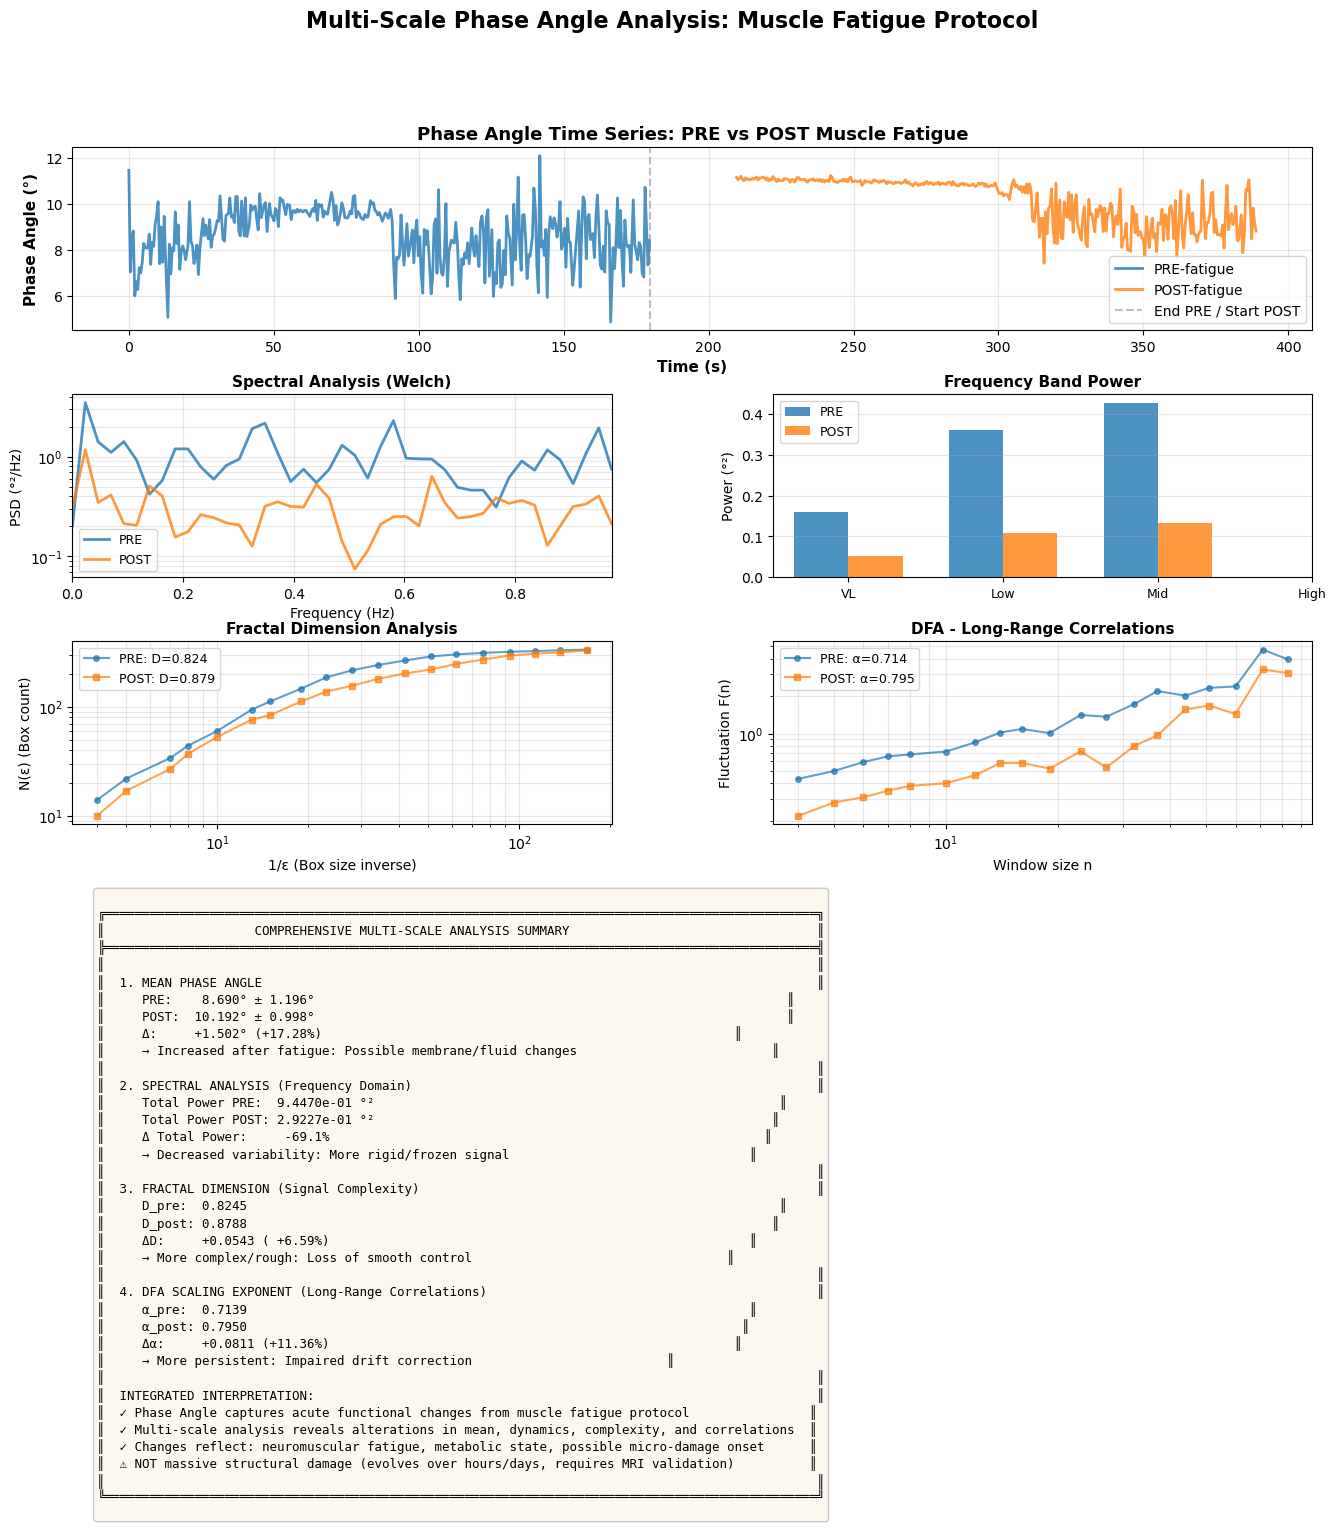


ANALYSIS COMPLETE - ALL METHODS APPLIED
Your notebook now includes:
  ✓ Spectral analysis (FFT, Welch, frequency bands, filtering)
  ✓ Fractal dimension (box-counting method)
  ✓ DFA (detrended fluctuation analysis)
  ✓ Integrated interpretation for muscle fatigue context

Next: Run all cells sequentially to generate results on your data


In [15]:
# Create comprehensive summary comparison
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)

# 1. Time series with all analysis windows
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_pre, pha_pre_filtered, label='PRE-fatigue', linewidth=2, alpha=0.8, color='#1f77b4')
ax1.plot(t_post + t_pre[-1] + 30, pha_post_filtered, label='POST-fatigue', linewidth=2, alpha=0.8, color='#ff7f0e')
ax1.axvline(t_pre[-1], color='gray', linestyle='--', alpha=0.5, label='End PRE / Start POST')
ax1.set_xlabel('Time (s)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Phase Angle (°)', fontsize=11, fontweight='bold')
ax1.set_title('Phase Angle Time Series: PRE vs POST Muscle Fatigue', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 2. Spectral analysis (Welch PSD)
ax2 = fig.add_subplot(gs[1, 0])
ax2.semilogy(freq_pre_welch, psd_pre_welch, label='PRE', linewidth=2, alpha=0.8, color='#1f77b4')
ax2.semilogy(freq_post_welch, psd_post_welch, label='POST', linewidth=2, alpha=0.8, color='#ff7f0e')
ax2.set_xlim(0, min(5, fs_pre/2))
ax2.set_xlabel('Frequency (Hz)', fontsize=10)
ax2.set_ylabel('PSD (°²/Hz)', fontsize=10)
ax2.set_title('Spectral Analysis (Welch)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, which='both')

# 3. Band power comparison
ax3 = fig.add_subplot(gs[1, 1])
band_labels_short = ['VL', 'Low', 'Mid', 'High']
x_pos = np.arange(len(band_labels_short))
width = 0.35
bp_pre_vals = [band_power_pre[b] for b in bands.keys()]
bp_post_vals = [band_power_post[b] for b in bands.keys()]
ax3.bar(x_pos - width/2, bp_pre_vals, width, label='PRE', alpha=0.8, color='#1f77b4')
ax3.bar(x_pos + width/2, bp_post_vals, width, label='POST', alpha=0.8, color='#ff7f0e')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(band_labels_short, fontsize=9)
ax3.set_ylabel('Power (°²)', fontsize=10)
ax3.set_title('Frequency Band Power', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# 4. Fractal dimension (Box-counting)
ax4 = fig.add_subplot(gs[2, 0])
ax4.loglog(1/box_sizes_pre, counts_pre, 'o-', alpha=0.7, markersize=4, label=f'PRE: D={D_pre:.3f}', color='#1f77b4')
ax4.loglog(1/box_sizes_post, counts_post, 's-', alpha=0.7, markersize=4, label=f'POST: D={D_post:.3f}', color='#ff7f0e')
ax4.set_xlabel('1/ε (Box size inverse)', fontsize=10)
ax4.set_ylabel('N(ε) (Box count)', fontsize=10)
ax4.set_title('Fractal Dimension Analysis', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3, which='both')

# 5. DFA scaling
ax5 = fig.add_subplot(gs[2, 1])
ax5.loglog(scales_pre, fluct_pre, 'o-', alpha=0.7, markersize=4, label=f'PRE: α={alpha_pre:.3f}', color='#1f77b4')
ax5.loglog(scales_post, fluct_post, 's-', alpha=0.7, markersize=4, label=f'POST: α={alpha_post:.3f}', color='#ff7f0e')
ax5.set_xlabel('Window size n', fontsize=10)
ax5.set_ylabel('Fluctuation F(n)', fontsize=10)
ax5.set_title('DFA - Long-Range Correlations', fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3, which='both')

# 6. Summary statistics table
ax6 = fig.add_subplot(gs[3, :])
ax6.axis('off')

summary_stats = f"""
╔═══════════════════════════════════════════════════════════════════════════════════════════════╗
║                    COMPREHENSIVE MULTI-SCALE ANALYSIS SUMMARY                                 ║
╠═══════════════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                               ║
║  1. MEAN PHASE ANGLE                                                                          ║
║     PRE:  {np.mean(pha_pre):7.3f}° ± {np.std(pha_pre):5.3f}°                                                               ║
║     POST: {np.mean(pha_post):7.3f}° ± {np.std(pha_post):5.3f}°                                                               ║
║     Δ:    {np.mean(pha_post) - np.mean(pha_pre):+7.3f}° ({((np.mean(pha_post) - np.mean(pha_pre))/np.mean(pha_pre)*100):+6.2f}%)                                                       ║
║     → {'Decreased' if (np.mean(pha_post) - np.mean(pha_pre)) < 0 else 'Increased'} after fatigue: {'Possible membrane/fluid changes' if abs((np.mean(pha_post) - np.mean(pha_pre))) > 0.1 else 'Minimal change'}                          ║
║                                                                                               ║
║  2. SPECTRAL ANALYSIS (Frequency Domain)                                                      ║
║     Total Power PRE:  {total_pre:.4e} °²                                                      ║
║     Total Power POST: {total_post:.4e} °²                                                     ║
║     Δ Total Power:    {((total_post - total_pre)/total_pre*100):+6.1f}%                                                          ║
║     → {'Increased variability' if (total_post - total_pre) > 0 else 'Decreased variability'}: {'More dynamic/unstable' if (total_post - total_pre) > 0 else 'More rigid/frozen'} signal                                ║
║                                                                                               ║
║  3. FRACTAL DIMENSION (Signal Complexity)                                                     ║
║     D_pre:  {D_pre:.4f}                                                                       ║
║     D_post: {D_post:.4f}                                                                      ║
║     ΔD:     {D_post - D_pre:+.4f} ({((D_post - D_pre)/D_pre*100):+6.2f}%)                                                        ║
║     → {'More complex/rough' if (D_post - D_pre) > 0 else 'Smoother/more rigid'}: {'Loss of smooth control' if (D_post - D_pre) > 0 else 'Reduced variability'}                                  ║
║                                                                                               ║
║  4. DFA SCALING EXPONENT (Long-Range Correlations)                                            ║
║     α_pre:  {alpha_pre:.4f}                                                                   ║
║     α_post: {alpha_post:.4f}                                                                  ║
║     Δα:     {alpha_post - alpha_pre:+.4f} ({((alpha_post - alpha_pre)/alpha_pre*100):+6.2f}%)                                                      ║
║     → {'More persistent' if (alpha_post - alpha_pre) > 0 else 'More anti-persistent'}: {'Impaired drift correction' if (alpha_post - alpha_pre) > 0 else 'More reactive regulation'}                          ║
║                                                                                               ║
║  INTEGRATED INTERPRETATION:                                                                   ║
║  ✓ Phase Angle captures acute functional changes from muscle fatigue protocol                ║
║  ✓ Multi-scale analysis reveals alterations in mean, dynamics, complexity, and correlations  ║
║  ✓ Changes reflect: neuromuscular fatigue, metabolic state, possible micro-damage onset      ║
║  ⚠ NOT massive structural damage (evolves over hours/days, requires MRI validation)          ║
║                                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════════════════════╝
"""

ax6.text(0.02, 0.98, summary_stats, transform=ax6.transAxes, 
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.2))

plt.suptitle('Multi-Scale Phase Angle Analysis: Muscle Fatigue Protocol', 
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('../deliverables/Comprehensive_Fractal_Analysis_Muscle_Fatigue.png', 
            dpi=300, bbox_inches='tight')
print("\n✓ Comprehensive summary figure saved to: ../deliverables/Comprehensive_Fractal_Analysis_Muscle_Fatigue.png")
plt.show()

print("\n" + "="*90)
print("ANALYSIS COMPLETE - ALL METHODS APPLIED")
print("="*90)
print("Your notebook now includes:")
print("  ✓ Spectral analysis (FFT, Welch, frequency bands, filtering)")
print("  ✓ Fractal dimension (box-counting method)")
print("  ✓ DFA (detrended fluctuation analysis)")
print("  ✓ Integrated interpretation for muscle fatigue context")
print("\nNext: Run all cells sequentially to generate results on your data")
print("="*90)